# Лабораторна робота № 1

## Вхідний аналіз набору даних

**Дисципліна:** Інтелектуальний аналіз та візуалізація даних (СК26)
**Тривалість:** 2 год аудиторно + 3 год самостійної роботи · **Максимальна оцінка:** 4 бали

---

### Мета роботи

Пригадати роботу в Jupyter Notebook, бібліотеці `pandas` та побудову графіків —
і зробити це не на навчальному прикладі, а на реальному файлі, який ніхто не готував
спеціально для вас.

Ця робота виконується **до першої лекції**. Нічого нового знати не потрібно: усе,
що знадобиться, ви вже проходили в попередніх курсах. Усі поняття, яких ви тут
торкнетеся мимохідь, отримають назви й пояснення на лекціях 3 і 4.

### Дані

Файл `20171129_FINAL_FINAL.xlsx`, аркуш `Sheet1` — спостереження космічної погоди
за 28 серпня — 22 вересня 2017 року, зібрані з трьох різних джерел.

Файл видається **як є**, рівно в тому вигляді, у якому його колись вивантажили.
Ніхто не приводив його до ладу, і саме в цьому сенс: справжні дані здебільшого
надходять саме такими.

### Що ви маєте зробити

| Етап | Зміст | Де |
|---|---|---|
| 1 | Розібратися, що взагалі лежить у файлі | аудиторно |
| 2 | Виділити три таблиці й привести їх до робочого вигляду | аудиторно |
| 3 | Скласти паспорт даних: що є, чого бракує, що виглядає дивно | аудиторно |
| 4 | Об'єднати три таблиці в одну | аудиторно |
| 5 | Побудувати п'ять графіків, кожен — відповідь на питання | аудиторно + самостійно |
| 6 | Порівняти два графіки одних і тих самих даних | самостійно |
| 7 | Записати три спостереження про дані | самостійно |
| 8 | Декларація про використання інструментів ШІ | самостійно |

### Що здається

1. Цей файл `.ipynb` із заповненими розв'язками. **Ноутбук має виконуватися згори
   донизу на чистому ядрі** (Kernel → Restart & Run All) без помилок — це перевіряється
   першою дією на захисті.
2. Файл `master_hourly.csv` — об'єднана таблиця з етапу 4.
3. Експорт ноутбука у HTML або PDF.
4. Заповнена декларація (етап 8). Без неї фінальна самоперевірка не проходить.

### Критерії оцінювання

| Бали | Що досягнуто |
|---|---|
| 0 | Дані не опрацьовано, графіки не побудовано або побудовано з грубими помилками |
| 1 | Таблиці прочитано й кілька графіків побудовано, але типи графіків не відповідають даним, дивних значень не помічено |
| 2 | Таблиці розібрано й об'єднано, графіки коректні та підписані, але висновків під ними немає або вони формальні |
| 4 | Усе вище виконано, знайдено й пояснено дивні значення, під кожним графіком є змістовний висновок про дані |

**Головне про оцінку:** бали ставляться не за наявність графіка, а за речення під ним.
Код, який нічого не пояснює, коштує двох балів з чотирьох.

---
## Нагадування про Jupyter

Якщо давно не працювали — три речі, які знадобляться сьогодні:

* `Shift+Enter` виконує клітинку, `Esc` `A` / `Esc` `B` додає клітинку вище / нижче,
  `Esc` `M` перетворює клітинку на текстову (Markdown), `Esc` `Y` — назад на код.
* **Порядок виконання має значення.** Якщо ви правили клітинки в довільному порядку,
  результат може залежати від історії запусків. Перед здачею обов'язково
  **Kernel → Restart & Run All** — так ви побачите ноутбук очима викладача.
* Текстові клітинки — не прикраса. Висновки пишуться в них, а не в коментарях до коду.

---
## Крок 0. Ваші дані та варіант

Заповніть три змінні й виконайте обидві клітинки. Друга надрукує **ваше
індивідуальне завдання** — воно відрізняється від завдання сусіда.

In [1]:
ПІБ = 'Стик Назарій Олегович'        # напр. 'Шевченко Тарас'
ГРУПА = 'ШІ-32'      # напр. 'КН-31'
ВАРІАНТ = 17     # ваш номер за списком групи

assert ПІБ and ГРУПА and ВАРІАНТ, 'Заповніть ПІБ, ГРУПУ та ВАРІАНТ'

In [2]:
# --- клітинку не редагувати: вона видає ваше персональне завдання ------------
ПОТОКИ = ['P>1', 'P>5', 'P>10', 'P>30', 'P>50', 'P>100', 'E>0.8', 'E>2.0']

ПАРИ = [('швидкість вітру', 'густина вітру'),
        ('швидкість вітру', 'потік P>10'),
        ('густина вітру', 'потік P>1'),
        ('радіопотік F10.7', 'потік P>10'),
        ('радіопотік F10.7', 'швидкість вітру'),
        ('потік E>0.8', 'потік P>10')]

АГРЕГАТИ = ['середнє', 'максимум', 'медіана', 'мінімум']

ПИТАННЯ = [
    'Скільки годин за все вікно ваш потік перевищував своє власне медіанне значення?',
    'У яку добу середнє значення вашого потоку було найбільшим? А найменшим?',
    'О котрій годині доби потік E>0.8 у середньому найбільший? Побудуйте графік середнього за годинами доби.',
    'Яка частка рядків об’єднаної таблиці має пропуск хоча б в одному стовпці?',
    'У який день радіопотік F10.7 був найбільшим і чи збігається цей день з піком вашого потоку?',
    'Порівняйте медіану вашого потоку за перший і за другий тиждень спостережень. У скільки разів вони відрізняються?',
    'Скільки годин поспіль тривала найдовша неперервна серія «активних» годин (група з етапу 4)?',
    'Який зі стовпців об’єднаної таблиці має найбільший розкид відносно власного середнього?',
    'Яку частку сумарного значення вашого потоку за все вікно дали 24 години навколо піку?',
    'Скільки різних діб потрапило у групу «активні» і скільки — у групу «дуже активні»?',
]

i = int(ВАРІАНТ)
завдання = {
    'ваш потік':                      ПОТОКИ[(i * 3 + 1) % 8],
    'ваша пара для графіка 3':        ' та '.join(ПАРИ[(i * 5 + 2) % 6]),
    'ваш агрегат для етапу 4':        АГРЕГАТИ[(i * 5 + 1) % 4],
    'ваше додаткове питання':         ПИТАННЯ[(i * 11 + 5) % 10],
}

print('ІНДИВІДУАЛЬНЕ ЗАВДАННЯ · %s, %s, варіант %d' % (ПІБ, ГРУПА, i))
print('=' * 78)
for k, v in завдання.items():
    print('%-28s %s' % (k + ':', v))

ІНДИВІДУАЛЬНЕ ЗАВДАННЯ · Стик Назарій Олегович, ШІ-32, варіант 17
ваш потік:                   P>50
ваша пара для графіка 3:     радіопотік F10.7 та потік P>10
ваш агрегат для етапу 4:     медіана
ваше додаткове питання:      О котрій годині доби потік E>0.8 у середньому найбільший? Побудуйте графік середнього за годинами доби.


Далі за текстом **«ваш потік»** означає стовпець, названий у першому рядку завдання.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 40)
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False,
                     'axes.spines.right': False, 'font.size': 9})

ФАЙЛ = '20171129_FINAL_FINAL.xlsx'

---
# Етап 1. Що взагалі лежить у файлі

Перше правило роботи з незнайомими даними: спершу подивитися, потім рахувати.

### Завдання 1.1
Спробуйте прочитати аркуш `Sheet1` звичайним способом — `pd.read_excel(ФАЙЛ)` —
і виведіть перші рядки та типи стовпців.

*Очікуваний результат: результат буде дивним. Подивіться на назви стовпців і на
те, які там типи даних. Поясніть у наступній клітинці, чому так вийшло.*

In [4]:
df = pd.read_excel(ФАЙЛ)
display(df.head())
display(df.dtypes)

,Unnamed: 0,ftp://ftp.swpc.noaa.gov/pub/lists/particle/,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21,Unnamed: 22,Unnamed: 23,Unnamed: 24,Unnamed: 25,http://umtof.umd.edu/pm/crn/,Unnamed: 27,Unnamed: 28,Unnamed: 29,Unnamed: 30,Unnamed: 31
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,:Data_list: 20170901_Gs_part_5m.txt,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SOHO CELIAS Proton Monitor,NaN,NaN,NaN,NaN,NaN
2,NaN,:Created: 2017 Sep 02 0011 UTC,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Solar Wind Parameters for Carrington Rotation ...,NaN,NaN,NaN,NaN,NaN
3,NaN,"# Prepared by the U.S. Dept. of Commerce, NOAA...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Proton speed [km/sec],NaN,NaN,NaN,NaN,NaN
4,NaN,# Please send comments and suggestions to SWPC...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Proton density [protons per cubic centimeter],NaN,NaN,NaN,NaN,NaN


Unnamed: 0                                     float64
ftp://ftp.swpc.noaa.gov/pub/lists/particle/     object
Unnamed: 2                                      object
Unnamed: 3                                      object
Unnamed: 4                                      object
Unnamed: 5                                      object
Unnamed: 6                                      object
Unnamed: 7                                      object
Unnamed: 8                                      object
Unnamed: 9                                      object
Unnamed: 10                                     object
Unnamed: 11                                     object
Unnamed: 12                                     object
Unnamed: 13                                     object
Unnamed: 14                                     object
Unnamed: 15                                    float64
Unnamed: 16                                     object
Unnamed: 17                                     object
Unnamed: 1

**Відповідь 1.1:** *Звичайне читання дало такий результат, тому що функція pd.read_excel() за замовчуванням бере перший рядок аркуша як заголовки стовпців, але в цьому файлі на самому початку розташовані не таблиці з даними, а службовий текст.*

### Завдання 1.2
Прочитайте аркуш ще раз, але **без заголовка**: `pd.read_excel(ФАЙЛ, header=None)`.
Виведіть його розмір і подивіться на перші 30 рядків.

In [5]:
# ВАШ КОД
RAW = pd.read_excel(ФАЙЛ, header=None)
print("Розмір таблиці:", RAW.shape)
display(RAW.head(30))

Розмір таблиці: (7226, 32)


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31
0,NaN,ftp://ftp.swpc.noaa.gov/pub/lists/particle/,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,http://umtof.umd.edu/pm/crn/,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,:Data_list: 20170901_Gs_part_5m.txt,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SOHO CELIAS Proton Monitor,NaN,NaN,NaN,NaN,NaN
3,NaN,:Created: 2017 Sep 02 0011 UTC,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Solar Wind Parameters for Carrington Rotation ...,NaN,NaN,NaN,NaN,NaN
4,NaN,"# Prepared by the U.S. Dept. of Commerce, NOAA...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Proton speed [km/sec],NaN,NaN,NaN,NaN,NaN
5,NaN,# Please send comments and suggestions to SWPC...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Proton density [protons per cubic centimeter],NaN,NaN,NaN,NaN,NaN
6,NaN,#,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,NaN,# Label: P > 1 = Particles at >1 Mev,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"Measurement time (Year, Month, Day of Month, D...",NaN,NaN,NaN,NaN,NaN
8,NaN,# Label: P > 5 = Particles at >5 Mev,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,NaN,# Label: P >10 = Particles at >10 Mev,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Завдання 1.3
Для кожного стовпця порахуйте, скільки в ньому заповнених клітинок
(`RAW.notna().sum()`), і виведіть результат.

*Очікуваний результат: 32 числа. Серед них будуть нулі та згустки великих значень.
За цими згустками видно, що в аркуші **не одна таблиця, а кілька**, вставлені поруч.*

**Питання:** скільки таблиць в аркуші і які стовпці займає кожна?

In [6]:
# ВАШ КОД
display(RAW.notna().sum())

0        0
1     7223
2     7202
3     7202
4     7202
5     7203
6     7203
7     7198
8     7198
9     7198
10    7198
11    7198
12    7198
13    7198
14    7198
15       0
16      32
17      26
18      26
19      26
20       0
21       0
22       0
23       0
24     601
25     601
26     608
27     602
28     602
29     602
30     602
31     602
dtype: int64

**Відповідь 1.3:** *(скільки таблиць і які стовпці кожна займає)*

В аркуші знаходяться 3 окремі таблиці. Це видно зі згустків кількості заповнених клітинок:
- Перша таблиця: стовпці з 1 по 14 (в Excel це B–O). Вона має близько 7200 рядків.
- Друга таблиця: стовпці з 16 по 19 (в Excel це Q–T). Вона має близько 25 рядків.
- Третя таблиця: стовпці з 24 по 31 (в Excel це Y–AF). Вона має близько 600 рядків.

### Завдання 1.4
Над кожною таблицею є кілька текстових рядків — це службовий опис від тих, хто дані
збирав. Виведіть їх і випишіть для кожної таблиці **джерело даних та одиниці
вимірювання**.

*Це найкорисніші п'ять хвилин роботи: жодної з цих відомостей у самій таблиці немає,
і без них ви не знатимете, у чому вимірюєте.*

In [7]:
# ВАШ КОД
print("Таблиця A (стовпець 1)")
display(RAW.iloc[0:20, 1].dropna())

print("\nТаблиця B (стовпець 16) ")
display(RAW.iloc[10:20, 16].dropna())

print("\nТаблиця C (стовпець 24)")
display(RAW.iloc[0:10, 26].dropna())

Таблиця A (стовпець 1)


0           ftp://ftp.swpc.noaa.gov/pub/lists/particle/
2                   :Data_list: 20170901_Gs_part_5m.txt
3                        :Created: 2017 Sep 02 0011 UTC
4     # Prepared by the U.S. Dept. of Commerce, NOAA...
5     # Please send comments and suggestions to SWPC...
6                                                    # 
7                  # Label: P > 1 = Particles at >1 Mev
8                  # Label: P > 5 = Particles at >5 Mev
9                 # Label: P >10 = Particles at >10 Mev
10                # Label: P >30 = Particles at >30 Mev
11                # Label: P >50 = Particles at >50 Mev
12               # Label: P>100 = Particles at >100 Mev
13               # Label: E>0.8 = Electrons at >0.8 Mev
14               # Label: E>2.0 = Electrons at >2.0 Mev
15               # Label: E>4.0 = Electrons at >4.0 Mev
16                # Units: Particles = Protons/cm2-s-sr
17              # Units: Electrons = Electrons/cm2-s-sr
18                                    # Source: 


Таблиця B (стовпець 16) 


13    ftp://ftp.swpc.noaa.gov/pub/indices/old_indice...
15       Product: Daily Solar Data         quar_DSD.txt
16                         :Issued: 0825 UT 04 Oct 2017
17                                                    #
18    #  Prepared by the U.S. Dept. of Commerce, NOA...
19    #  Please send comments and suggestions to SWP...
Name: 16, dtype: object


Таблиця C (стовпець 24)


0                         http://umtof.umd.edu/pm/crn/
2                           SOHO CELIAS Proton Monitor
3    Solar Wind Parameters for Carrington Rotation ...
4                                Proton speed [km/sec]
5        Proton density [protons per cubic centimeter]
7    Measurement time (Year, Month, Day of Month, D...
Name: 26, dtype: object

**Відповідь 1.4:**

| Таблиця | Джерело | Одиниці вимірювання |
|---|---|---|
| A | Супутник GOES-15 (NOAA) | Протони: Protons/cm2-s-sr, Електрони: Electrons/cm2-s-sr |
| B | NOAA / Daily Solar Data | Індекс радіопотоку (без конкретних одиниць, просто Radio Flux 10.7) |
| C | SOHO CELIAS Proton Monitor | Швидкість: km/sec, Густина: protons per cubic centimeter |


---
# Етап 2. Три таблиці в робочому вигляді

У файлі три таблиці. Ось що в них лежить — решту ви вже знайшли самі:

| Таблиця | Стовпці аркуша | Що це | Один рядок = |
|---|---|---|---|
| A | B–O | вимірювання із супутника GOES-15: потоки частинок різної енергії | 5 хвилин |
| B | Q–T | добовий показник сонячної активності F10.7 | доба |
| C | Y–AF | швидкість і густина сонячного вітру | година |

### Завдання 2.1
Виділіть кожну таблицю в окремий `DataFrame` — назвіть їх `A`, `B` і `C`.
Дайте стовпцям осмислені назви й перетворіть значення на числа
(`pd.to_numeric(..., errors='coerce')` стане в пригоді).

In [8]:
# ВАШ КОД

A = RAW.iloc[26:, 1:15].copy()
A.columns = ['year', 'month', 'day', 'hhmm', 'julian', 'seconds', 
             'P>1', 'P>5', 'P>10', 'P>30', 'P>50', 'P>100', 'E>0.8', 'E>2.0']

B = RAW.iloc[27:52, 16:20].copy() 
B.columns = ['year', 'month', 'day', 'F10.7']

C = RAW.iloc[27:628, 26:32].copy() 
C.columns = ['year', 'month', 'day', 'hour', 'speed', 'density']

A = A.apply(pd.to_numeric, errors='coerce')
B = B.apply(pd.to_numeric, errors='coerce')
C = C.apply(pd.to_numeric, errors='coerce')

print(f"Розмір A: {A.shape} (очікувано 7200 рядків)")
print(f"Розмір B: {B.shape} (очікувано 25 рядків)")
print(f"Розмір C: {C.shape} (очікувано 601 рядок)")


Розмір A: (7200, 14) (очікувано 7200 рядків)
Розмір B: (25, 4) (очікувано 25 рядків)
Розмір C: (601, 6) (очікувано 601 рядок)


### Завдання 2.2
У кожній таблиці дата й час записані **по-різному** й розкидані по кількох стовпцях.
Зберіть для кожної таблиці один стовпець `ts` типу `datetime`.

Після цього обов'язково виведіть для кожної таблиці найранішу й найпізнішу дату.

*Очікуваний результат: усі три таблиці мають лежати в межах серпня–вересня 2017 року.
Якщо у вас вийшов інший рік — придивіться, як записано рік у тій таблиці, і виправте.*

In [9]:
# ВАШ КОД
A['ts'] = pd.to_datetime({
    'year': A['year'],
    'month': A['month'],
    'day': A['day'],
    'hour': A['hhmm'] // 100, 
    'minute': A['hhmm'] % 100
})

B['ts'] = pd.to_datetime({
    'year': B['year'],
    'month': B['month'],
    'day': B['day']
})

C['ts'] = pd.to_datetime({
    'year': C['year'] + 2000, 
    'month': C['month'],
    'day': C['day'],
    'hour': C['hour']
})

print("Межі Таблиці A:", A['ts'].min(), "—", A['ts'].max())
print("Межі Таблиці B:", B['ts'].min(), "—", B['ts'].max())
print("Межі Таблиці C:", C['ts'].min(), "—", C['ts'].max())

Межі Таблиці A: 2017-08-28 00:00:00 — 2017-09-21 23:55:00
Межі Таблиці B: 2017-08-28 00:00:00 — 2017-09-21 00:00:00
Межі Таблиці C: 2017-08-28 00:00:00 — 2017-09-22 00:00:00


**Самоперевірка етапу 2.** Клітинка має виконатися без помилок.

In [10]:
assert len(A) == 7200, 'у таблиці A має бути 7200 рядків, а є %d' % len(A)
assert len(B) == 25,   'у таблиці B має бути 25 рядків, а є %d' % len(B)
assert len(C) == 601,  'у таблиці C має бути 601 рядок, а є %d' % len(C)
for назва, т in [('A', A), ('B', B), ('C', C)]:
    рік = pd.to_datetime(т['ts']).dt.year
    assert рік.min() == 2017 and рік.max() == 2017, 'у таблиці %s рік не 2017 — перевірте збирання дати' % назва
print('Етап 2 пройдено')

Етап 2 пройдено


---
# Етап 3. Паспорт даних

### Завдання 3.1
Для кожної таблиці виведіть: розмір, типи стовпців, кількість пропусків у кожному
стовпці, кількість повних дублікатів рядків і описові статистики (`describe()`).

In [11]:
# ВАШ КОД

for name, df in [('A', A), ('B', B), ('C', C)]:
    print(f"============== ТАБЛИЦЯ {name} ==============")
    
    print(f"Розмір: {df.shape}")
    
    print(f"Повних дублікатів: {df.duplicated().sum()}")
    
    print("\n--- Пропуски ---")
    print(df.isna().sum())
    
    print("\n--- Типи даних ---")
    print(df.dtypes)
    
    print("\n--- Описові статистики ---")
    display(df.describe())
    print("\n\n")

============== ТАБЛИЦЯ A ==============
Розмір: (7200, 15)
Повних дублікатів: 0

--- Пропуски ---
year       0
month      0
day        0
hhmm       0
julian     0
seconds    0
P>1        3
P>5        3
P>10       3
P>30       3
P>50       3
P>100      3
E>0.8      3
E>2.0      3
ts         0
dtype: int64

--- Типи даних ---
year                int64
month               int64
day                 int64
hhmm                int64
julian              int64
seconds             int64
P>1               float64
P>5               float64
P>10              float64
P>30              float64
P>50              float64
P>100             float64
E>0.8             float64
E>2.0             float64
ts         datetime64[us]
dtype: object

--- Описові статистики ---


,year,month,day,hhmm,julian,seconds,P>1,P>5,P>10,P>30,P>50,P>100,E>0.8,E>2.0,ts
count,7200.0,7200.000000,7200.000000,7200.000000,7200.000000,7200.000000,7197.000000,7197.000000,7197.000000,7197.000000,7197.000000,7197.00000,7197.000000,7197.000000,7200
mean,2017.0,8.840000,13.960000,1177.500000,58005.000000,43050.000000,689.325064,156.626057,76.474020,18.838604,7.446840,1.65929,81862.741801,11401.502123,2017-09-09 11:57:30
min,2017.0,8.000000,1.000000,0.000000,57993.000000,0.000000,0.429000,0.151000,0.117000,0.057600,0.045500,0.02240,4.300000,0.133000,2017-08-28 00:00:00
25%,2017.0,9.000000,7.000000,588.750000,57999.000000,21525.000000,11.700000,0.279000,0.186000,0.098400,0.059700,0.02630,22200.000000,552.000000,2017-09-03 05:58:45
50%,2017.0,9.000000,13.000000,1177.500000,58005.000000,43050.000000,55.400000,0.632000,0.376000,0.146000,0.086600,0.03630,68600.000000,4290.000000,2017-09-09 11:57:30
75%,2017.0,9.000000,19.000000,1766.250000,58011.000000,64575.000000,560.000000,107.000000,35.800000,0.990000,0.249000,0.06700,143000.000000,14100.000000,2017-09-15 17:56:15
max,2017.0,9.000000,31.000000,2355.000000,58017.000000,86100.000000,32500.000000,2890.000000,1330.000000,399.000000,191.000000,61.50000,259000.000000,110000.000000,2017-09-21 23:55:00
std,0.0,0.366632,8.775483,692.481902,7.211603,24943.113498,1625.968447,390.921861,222.362627,67.265595,28.620524,7.15889,65728.005824,16920.617446,NaN





============== ТАБЛИЦЯ B ==============
Розмір: (25, 5)
Повних дублікатів: 0

--- Пропуски ---
year     0
month    0
day      0
F10.7    0
ts       0
dtype: int64

--- Типи даних ---
year              int64
month             int64
day               int64
F10.7             int64
ts       datetime64[us]
dtype: object

--- Описові статистики ---


,year,month,day,F10.7,ts
count,25.0,25.000000,25.000000,25.000000,25
mean,2017.0,8.840000,13.960000,92.680000,2017-09-09 00:00:00
min,2017.0,8.000000,1.000000,71.000000,2017-08-28 00:00:00
25%,2017.0,9.000000,7.000000,74.000000,2017-09-03 00:00:00
50%,2017.0,9.000000,13.000000,84.000000,2017-09-09 00:00:00
75%,2017.0,9.000000,19.000000,107.000000,2017-09-15 00:00:00
max,2017.0,9.000000,31.000000,140.000000,2017-09-21 00:00:00
std,0.0,0.374166,8.955817,22.206831,NaN





============== ТАБЛИЦЯ C ==============
Розмір: (601, 7)
Повних дублікатів: 0

--- Пропуски ---
year       0
month      0
day        0
hour       0
speed      0
density    0
ts         0
dtype: int64

--- Типи даних ---
year                int64
month               int64
day                 int64
hour                int64
speed               int64
density           float64
ts         datetime64[us]
dtype: object

--- Описові статистики ---


,year,month,day,hour,speed,density,ts
count,601.0,601.000000,601.000000,601.000000,601.000000,601.000000,601
mean,17.0,8.840266,13.973378,11.480865,506.547421,2.907654,2017-09-09 12:00:00
min,17.0,8.000000,1.000000,0.000000,-1.000000,-1.000000,2017-08-28 00:00:00
25%,17.0,9.000000,7.000000,5.000000,447.000000,1.800000,2017-09-03 06:00:00
50%,17.0,9.000000,13.000000,11.000000,517.000000,2.400000,2017-09-09 12:00:00
75%,17.0,9.000000,19.000000,17.000000,584.000000,3.400000,2017-09-15 18:00:00
max,17.0,9.000000,31.000000,23.000000,806.000000,31.700000,2017-09-22 00:00:00
std,0.0,0.366664,8.781000,6.938063,125.073291,2.637873,NaN


### Завдання 3.2 — дивні значення
Подивіться на рядок `min` у таблиці `describe()` для таблиці C.

Швидкість і густина — фізичні величини, які **не можуть бути від'ємними**.
Знайдіть від'ємні значення, порахуйте, скільки їх, і поверніться до службового опису
з завдання 1.4: там написано, що вони означають.

Замініть ці значення на `NaN` і покажіть, як після цього змінилися середнє й мінімум.

*Очікуваний результат: два числа «до» і «після» для кожного зі стовпців.*

In [12]:
# ВАШ КОД

neg_speed = (C['speed'] < 0).sum()
neg_density = (C['density'] < 0).sum()
print(f"Від'ємних швидкостей: {neg_speed}")
print(f"Від'ємних густин: {neg_density}")

print("\n- ДО ЗАМІНИ")
print(f"Швидкість: середнє = {C['speed'].mean():.2f}, мінімум = {C['speed'].min()}")
print(f"Густина: середнє = {C['density'].mean():.2f}, мінімум = {C['density'].min()}")

C.loc[C['speed'] < 0, 'speed'] = np.nan
C.loc[C['density'] < 0, 'density'] = np.nan

print("\n- ПІСЛЯ ЗАМІНИ")
print(f"Швидкість: середнє = {C['speed'].mean():.2f}, мінімум = {C['speed'].min()}")
print(f"Густина: середнє = {C['density'].mean():.2f}, мінімум = {C['density'].min()}")

Від'ємних швидкостей: 8
Від'ємних густин: 8

- ДО ЗАМІНИ
Швидкість: середнє = 506.55, мінімум = -1
Густина: середнє = 2.91, мінімум = -1.0

- ПІСЛЯ ЗАМІНИ
Швидкість: середнє = 513.39, мінімум = 277.0
Густина: середнє = 2.96, мінімум = 0.1


**Відповідь 3.2:** *(що це за значення, скільки їх, як вони спотворювали середнє)*

Від'ємні значення (-1) у цьому наборі даних означають відсутні вимірювання (missing data) або збій датчика. Їх виявилося по 8 штук у стовпцях швидкості та густини. Через те, що система сприймала їх як реальні числа, середнє значення було штучно занижене. Після заміни цих значень на NaN, мінімуми стали коректними (додатними), а середнє значення трохи зросло і тепер відображає реальну фізичну картину.

### Завдання 3.3 — питання на подумати
У таблиці A є стовпці, для яких `describe()` слухняно рахує середнє й стандартне
відхилення, хоча ці числа не мають жодного сенсу.

Знайдіть їх і поясніть своїми словами, чому середнє для них безглузде.

*Підказка: не кожне число в таблиці є результатом вимірювання.*

> Це питання не має однієї «правильної» відповіді з підручника — на нього ви
> відповідаєте з власного здорового глузду. Формальне пояснення буде на лекції 3.

In [13]:
# ВАШ КОД
display(A[['year', 'month', 'day', 'hhmm', 'julian', 'seconds']].describe())

,year,month,day,hhmm,julian,seconds
count,7200.0,7200.000000,7200.000000,7200.000000,7200.000000,7200.000000
mean,2017.0,8.840000,13.960000,1177.500000,58005.000000,43050.000000
std,0.0,0.366632,8.775483,692.481902,7.211603,24943.113498
min,2017.0,8.000000,1.000000,0.000000,57993.000000,0.000000
25%,2017.0,9.000000,7.000000,588.750000,57999.000000,21525.000000
50%,2017.0,9.000000,13.000000,1177.500000,58005.000000,43050.000000
75%,2017.0,9.000000,19.000000,1766.250000,58011.000000,64575.000000
max,2017.0,9.000000,31.000000,2355.000000,58017.000000,86100.000000


**Відповідь 3.3:** *(які це стовпці та чому середнє для них не має сенсу)*

Стовпці, для яких не потрібно рахувати середнє значення, це `year`, `month`, `day`, `hhmm`, `julian`, `seconds`. Вони просто показують дату та час, коли проводилося спостереження. Тому знаходити їх середнє значення немає особливого сенсу, адже це не дає корисної інформації про стан космічної погоди.


---
# Етап 4. Об'єднання трьох таблиць в одну

Таблиці мають різний крок у часі: 5 хвилин, година і доба. Щоб працювати з ними
разом, потрібна спільна сітка. Беремо **годину**.

Кожна таблиця потребує своєї дії:

1. **A: 5 хвилин → година.** Кілька рядків згортаються в один — це `resample` + агрегація.
2. **C: уже година.** Просте з'єднання по спільному стовпцю `ts` — `merge`.
3. **B: доба → година.** Навпаки, одне значення розтягується на 24 години доби.

### Завдання 4.1
Зведіть таблицю A до погодинної сітки. Для кожного потоку порахуйте **два** числа
за годину: середнє і максимум.

In [14]:
# ВАШ КОД

A_numeric = A[['ts', 'P>1', 'P>5', 'P>10', 'P>30', 'P>50', 'P>100', 'E>0.8', 'E>2.0']].copy()

A_numeric.set_index('ts', inplace=True)

A_hourly = A_numeric.resample('1h').agg(['mean', 'max'])

A_hourly = A_hourly.reset_index()

A_hourly.columns = [f"{col[0]}_{col[1]}" if col[1] else col[0] for col in A_hourly.columns]

print("Розмір Таблиці A після згортання до годин:", A_hourly.shape)
display(A_hourly.head())

Розмір Таблиці A після згортання до годин: (600, 17)


,ts,P>1_mean,P>1_max,P>5_mean,P>5_max,P>10_mean,P>10_max,P>30_mean,P>30_max,P>50_mean,P>50_max,P>100_mean,P>100_max,E>0.8_mean,E>0.8_max,E>2.0_mean,E>2.0_max
0,2017-08-28 00:00:00,9.778333,19.40,0.324917,0.690,0.192917,0.314,0.098850,0.2240,0.077583,0.1780,0.040692,0.0793,20941.666667,23600.0,1011.583333,1180.0
1,2017-08-28 01:00:00,7.994167,13.60,0.291667,0.512,0.156583,0.259,0.072583,0.0919,0.058700,0.0798,0.029950,0.0471,18091.666667,20600.0,713.000000,907.0
2,2017-08-28 02:00:00,6.099167,10.80,0.283000,0.479,0.177667,0.321,0.084450,0.1210,0.069642,0.1110,0.035025,0.0595,14108.333333,15000.0,380.833333,475.0
3,2017-08-28 03:00:00,4.752500,7.76,0.236833,0.329,0.166333,0.244,0.087658,0.1800,0.068092,0.1390,0.035517,0.0818,12766.666667,13100.0,267.916667,284.0
4,2017-08-28 04:00:00,4.158333,6.62,0.334917,0.539,0.208333,0.309,0.084800,0.1530,0.072850,0.1420,0.039708,0.0694,11333.333333,12300.0,203.000000,234.0


### Завдання 4.2
У вашому завданні названо агрегат (`середнє`, `максимум`, `медіана` або `мінімум`).

Візьміть ваш потік за одну добу, порахуйте для нього по годинах ваш агрегат і ще один
на ваш вибір, і побудуйте обидві криві на одному графіку.

**Питання:** чим вони відрізняються і в якій ситуації різниця між ними стане суттєвою?

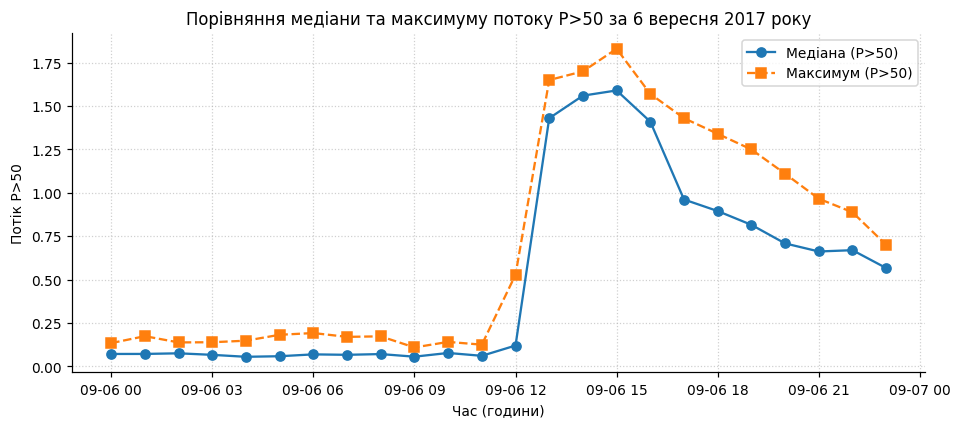

In [15]:
# ВАШ КОД

day_data = A_numeric.loc['2017-09-06'].copy()

hourly_stats = day_data['P>50'].resample('1h').agg(['median', 'max'])

plt.figure(figsize=(10, 4))
plt.plot(hourly_stats.index, hourly_stats['median'], label='Медіана (P>50)', marker='o')
plt.plot(hourly_stats.index, hourly_stats['max'], label='Максимум (P>50)', marker='s', linestyle='--')

plt.title('Порівняння медіани та максимуму потоку P>50 за 6 вересня 2017 року')
plt.xlabel('Час (години)')
plt.ylabel('Потік P>50')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

**Відповідь 4.2:** *(чим відрізняються криві та коли це важливо)*

Крива максимуму завжди знаходиться вище або на одному рівні з кривою медіани. Велика різниця між ними з'являється під час різких, але коротких сплесків потоку, наприклад, коли він сильно збільшується лише на 5–10 хвилин. Медіана не дуже реагує на такі короткочасні викиди і показує більш типовий рівень потоку P>50 протягом години. Максимум, навпаки, показує найбільше значення за цю годину. Тому максимум краще використовувати для пошуку різких сплесків, а медіану для оцінки звичайного рівня потоку.


### Завдання 4.3
Об'єднайте три таблиці в одну — назвіть її `M`. Виведіть її розмір і всі рядки,
у яких є хоча б один пропуск.

**Зверніть увагу:** таблиці закінчуються не в один і той самий момент. Тому результат
залежить від того, який тип об'єднання ви оберете (`how='inner'` чи `how='outer'`).
Спробуйте обидва, подивіться, чим відрізняється кількість рядків, і поясніть свій вибір.

In [16]:
# ВАШ КОД

# Готуємо B
hours_grid = pd.DataFrame({'ts': pd.date_range(start=B['ts'].min(), end=B['ts'].max() + pd.Timedelta(hours=23), freq='1h')})
B_hourly = pd.merge(hours_grid, B[['ts', 'F10.7']], on='ts', how='left').ffill()


# Об'єднання
M_inner = pd.merge(A_hourly, C[['ts', 'speed', 'density']], on='ts', how='inner')
M_inner = pd.merge(M_inner, B_hourly, on='ts', how='inner')

M_outer = pd.merge(A_hourly, C[['ts', 'speed', 'density']], on='ts', how='outer')
M_outer = pd.merge(M_outer, B_hourly, on='ts', how='outer')

print(f"Рядковий розмір при 'inner': {len(M_inner)}")
print(f"Рядковий розмір при 'outer': {len(M_outer)}")

M = M_inner.copy()

M_with_na = M[M.isna().any(axis=1)]
print(f"\nРядків із пропуском у таблиці M: {len(M_with_na)}")
display(M_with_na.head())


Рядковий розмір при 'inner': 600
Рядковий розмір при 'outer': 601

Рядків із пропуском у таблиці M: 8


,ts,P>1_mean,P>1_max,P>5_mean,P>5_max,P>10_mean,P>10_max,P>30_mean,P>30_max,P>50_mean,P>50_max,P>100_mean,P>100_max,E>0.8_mean,E>0.8_max,E>2.0_mean,E>2.0_max,speed,density,F10.7
175,2017-09-04 07:00:00,6.465833,10.10,0.262083,0.593,0.171500,0.294,0.085483,0.145,0.068558,0.134,0.031717,0.0523,90600.000000,100000.0,7410.833333,8950.0,NaN,NaN,140.0
176,2017-09-04 08:00:00,4.010833,5.08,0.256000,0.432,0.195833,0.336,0.086625,0.145,0.070033,0.134,0.036492,0.0546,73483.333333,79300.0,5048.333333,5850.0,NaN,NaN,140.0
177,2017-09-04 09:00:00,3.268333,4.42,0.303417,0.518,0.220333,0.302,0.105925,0.162,0.081975,0.134,0.046483,0.0765,60475.000000,68500.0,3715.833333,4480.0,NaN,NaN,140.0
178,2017-09-04 10:00:00,3.179167,4.74,0.252167,0.372,0.181833,0.280,0.101900,0.150,0.081675,0.120,0.054125,0.0894,64383.333333,68400.0,4122.500000,4710.0,NaN,NaN,140.0
179,2017-09-04 11:00:00,5.274167,7.98,0.295083,0.657,0.186917,0.276,0.089525,0.166,0.063983,0.110,0.033633,0.0684,79933.333333,88200.0,6345.833333,7430.0,NaN,NaN,140.0


**Відповідь 4.3:** *(який тип об'єднання обрано, скільки рядків дає кожен і чому)*

При об'єднанні таблиць типом `inner` отримали 600 рядків, а типом `outer` — 601. Це тому, що в таблиці C (сонячний вітер) є ще одна додаткова година — 22 вересня, якої немає в таблиці A. При `outer` ця година додається до загальної таблиці, а відсутні дані заповнюються значеннями `NaN`.

Я обрав `inner`, щоб залишити тільки ті години, для яких є дані з усіх трьох таблиць одночасно. У результаті отримав 600 годин. 8 рядків з пропусками в таблиці `M` залишилися через збої датчиків. Наприклад, це можуть бути аномальні значення швидкості вітру, які на попередньому етапі були замінені на `NaN`.


### Завдання 4.4 — поділ на групи
Щоб далі було що з чим порівнювати, поділіть години на три групи за значенням
**максимуму потоку P>10 за годину**:

| Група | Умова |
|---|---|
| `тиха` | менше 10 |
| `активна` | від 10 до 1000 |
| `дуже активна` | 1000 і більше |

Додайте до `M` стовпець `група` і виведіть, скільки годин потрапило в кожну.

> Це не вигадані числа: саме такі пороги використовує метеослужба космічної погоди
> NOAA. Чому вони саме такі — питання не сьогоднішньої роботи.

In [17]:
# ВАШ КОД

bins = [-np.inf, 10, 1000, np.inf]
labels = ['тиха', 'активна', 'дуже активна']

M['група'] = pd.cut(M['P>10_max'], bins=bins, labels=labels, right=False)

print("Кількість годин у кожній групі:")
print(M['група'].value_counts())

Кількість годин у кожній групі:
група
тиха            411
активна         171
дуже активна     18
Name: count, dtype: int64


**Самоперевірка етапу 4.**

In [18]:
assert M is not None, 'таблиця M не побудована'
assert 'ts' in M.columns, 'у таблиці M потрібен стовпець ts'
assert 'група' in M.columns, 'у таблиці M потрібен стовпець «група»'
assert 590 <= len(M) <= 605, 'очікується близько 600 рядків, а є %d — перевірте об’єднання' % len(M)
print('Етап 4 пройдено:', len(M), 'рядків')

Етап 4 пройдено: 600 рядків


---
# Етап 5. П'ять графіків — п'ять питань

Графік будується як **відповідь на питання**, а не «щоб був».

**Вимоги до кожного графіка:**

* підписані обидві осі, з одиницями вимірювання;
* заголовок;
* під графіком, у текстовій клітинці, — **одне речення про дані**.
  Не «на графіку зображено потік протонів», а твердження на кшталт
  «більшість годин потік не перевищує 60, але кілька годин дають значення у сотні разів більші».

> Не кожне питання має відповідь «так, зв'язок є». Якщо на графіку нічого не видно —
> так і напишіть. Відсутність зв'язку — це теж результат, і чесно про неї написати
> важливіше, ніж підбирати ракурс, у якому «щось наче проглядається».

### Графік 1. Як розподілені значення вашого потоку?
Побудуйте гістограму вашого потоку (середнє за годину). Порахуйте окремо середнє
й медіану цього стовпця.

Якщо гістограма вийде нечитабельною — стовпчик біля нуля і порожньо далі — не
залишайте так. Спробуйте побудувати гістограму від логарифма значень
(`np.log10`) і подивіться, що зміниться.

**Питання:** чому середнє й медіана так сильно відрізняються?

Середнє P>50: 7.4439
Медіана P>50: 0.0802
Середнє більше за медіану в 92.8 разів!



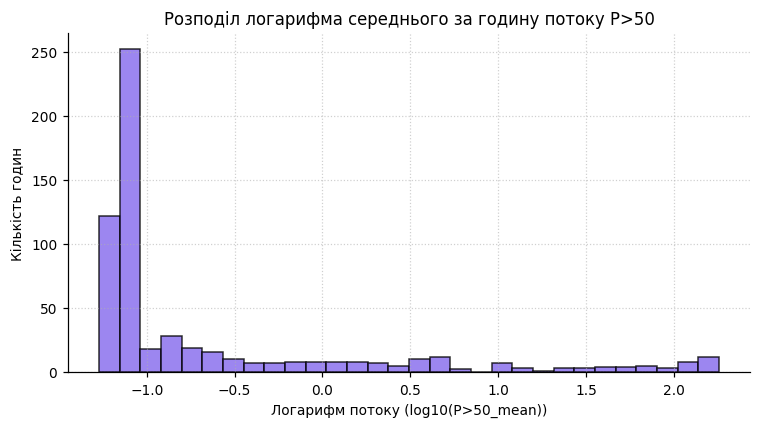

In [19]:
# ВАШ КОД

# середнє та медіана
mean_val = M['P>50_mean'].mean()
median_val = M['P>50_mean'].median()

print(f"Середнє P>50: {mean_val:.4f}")
print(f"Медіана P>50: {median_val:.4f}")
print(f"Середнє більше за медіану в {mean_val / median_val:.1f} разів!\n")

# гістограма від логарифма
plt.figure(figsize=(8, 4))

log_data = np.log10(M['P>50_mean'].dropna()) 
plt.hist(log_data, bins=30, color='#8368ed', edgecolor='black', alpha=0.8)

plt.title('Розподіл логарифма середнього за годину потоку P>50')
plt.xlabel('Логарифм потоку (log10(P>50_mean))')
plt.ylabel('Кількість годин')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

**Висновок:** Більшість часу потік P>50 залишається на досить низькому рівні, що і показує медіана. Але під час рідкісних сонячних спалахів його значення можуть різко зрости в тисячі разів. Через такі великі, але рідкісні значення середнє арифметичне сильно збільшується і вже не показує типовий рівень потоку.


### Графік 2. Чи відрізняється швидкість вітру між групами годин?
Побудуйте діаграму розмаху (`boxplot`) швидкості сонячного вітру окремо для кожної
групи з завдання 4.4.

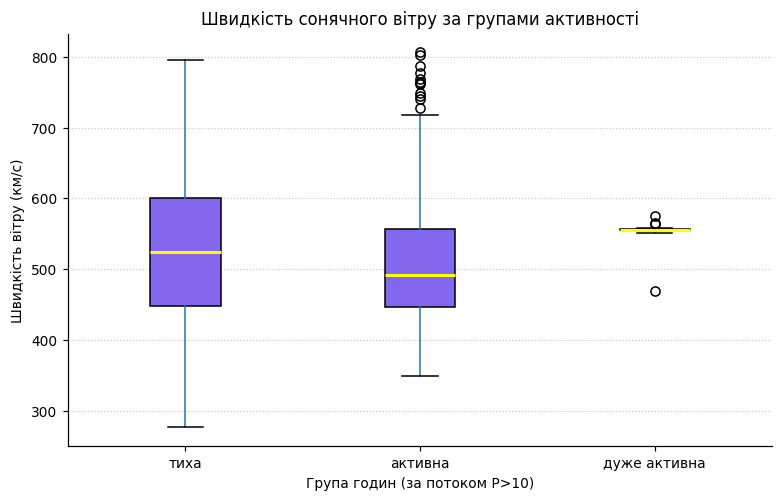

In [20]:
# ВАШ КОД

plt.figure(figsize=(8, 5))

M.boxplot(column='speed', by='група', ax=plt.gca(), grid=False, 
          patch_artist=True, boxprops=dict(facecolor='#8368ed', color='black'),
          medianprops=dict(color='yellow', linewidth=2))

plt.title('Швидкість сонячного вітру за групами активності')
plt.suptitle('')
plt.xlabel('Група годин (за потоком P>10)')
plt.ylabel('Швидкість вітру (км/с)')
plt.grid(axis='y', linestyle=':', alpha=0.7)
plt.show()

**Висновок:** Графік показує, що прямого зв'язку між потоком частинок P>10 і швидкістю сонячного вітру немає, оскільки значення швидкості в різних групах сильно перетинаються. Також медіанна швидкість вітру в «активній» групі виявилася трохи нижчою, ніж у «тихій». Вузький ящик «дуже активної» групи можна пояснити малою кількістю даних, оскільки це був короткочасний спалах. Отже, велика швидкість сонячного вітру не обов'язково означає, що потік протонів також буде дуже високим.


### Графік 3. Чи пов'язані змінні вашої пари?
Побудуйте діаграму розсіювання для пари з вашого завдання. Порахуйте коефіцієнт
кореляції між ними.

Коефіцієнт кореляції між F10.7 та P>10: -0.0519



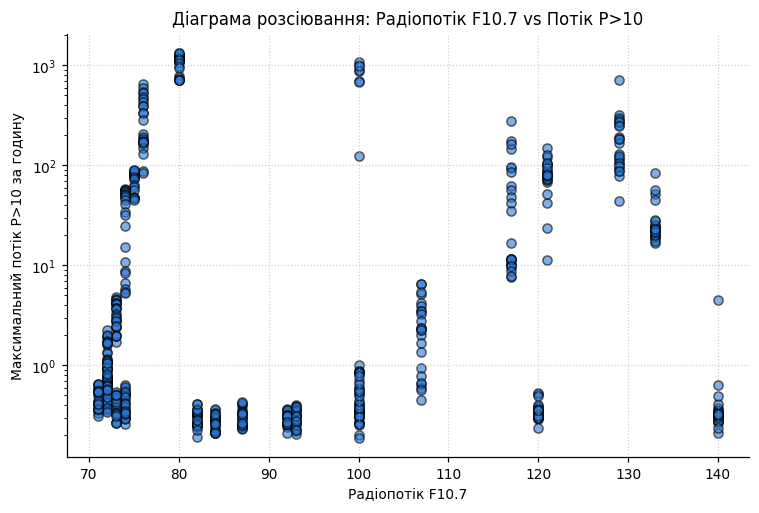

In [21]:
# ВАШ КОД

# коефіцієнт кореляції
correlation = M['F10.7'].corr(M['P>10_max'])
print(f"Коефіцієнт кореляції між F10.7 та P>10: {correlation:.4f}\n")

plt.figure(figsize=(8, 5))
plt.scatter(M['F10.7'], M['P>10_max'], alpha=0.6, color='#2a78d6', edgecolor='black')

plt.title('Діаграма розсіювання: Радіопотік F10.7 vs Потік P>10')
plt.xlabel('Радіопотік F10.7')
plt.ylabel('Максимальний потік P>10 за годину')

plt.yscale('log') 
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

**Висновок:** Коефіцієнт кореляції дуже близький до нуля (приблизно -0.05), а на діаграмі точки розташовані хаотично і не мають чіткої залежності. Це означає, що прямого лінійного зв'язку між радіопотоком F10.7 та потоком протонів P>10 у цьому періоді немає. Тобто збільшення радіопотоку не обов'язково призводить до збільшення кількості протонів.


### Графік 4. Скільки годин у кожній групі?
Побудуйте стовпчикову діаграму кількості годин за групами. Підпишіть кожен стовпчик
кількістю годин і відсотком від загальної кількості.

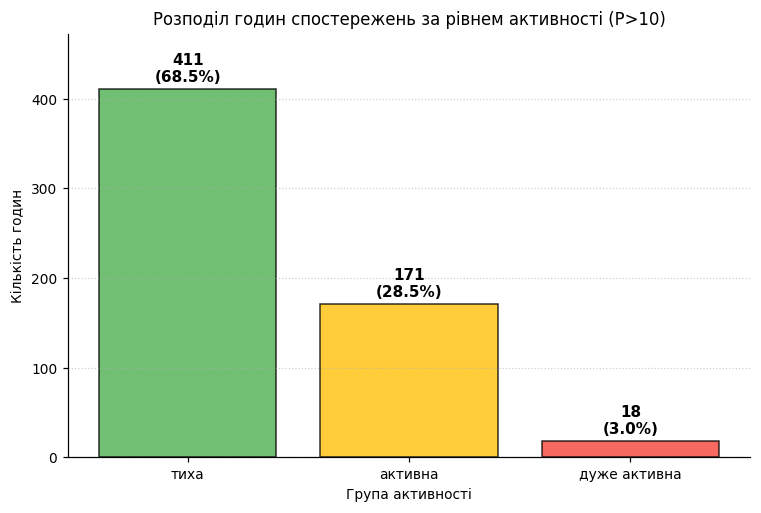

In [22]:
# ВАШ КОД

group_counts = M['група'].value_counts()
total_hours = len(M)

plt.figure(figsize=(8, 5))
bars = plt.bar(group_counts.index, group_counts.values, 
               color=['#4CAF50', '#FFC107', '#F44336'], edgecolor='black', alpha=0.8)

for bar in bars:
    height = bar.get_height()
    percentage = (height / total_hours) * 100
    plt.text(bar.get_x() + bar.get_width() / 2, height + 5, 
             f'{int(height)}\n({percentage:.1f}%)', 
             ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.title('Розподіл годин спостережень за рівнем активності (P>10)')
plt.xlabel('Група активності')
plt.ylabel('Кількість годин')

plt.ylim(0, group_counts.max() * 1.15)
plt.grid(axis='y', linestyle=':', alpha=0.6)
plt.show()

**Висновок:** Більшу частину часу (майже 68,5%, або 411 годин) космічна погода була у спокійному, «тихому» стані. Періоди дуже сильних потоків протонів («дуже активна» група) зустрічалися досить рідко і становили лише 3% (18 годин) від усього періоду спостережень.


### Графік 5. Як усе це виглядало в часі?
Побудуйте лінійний графік максимуму потоку P>10 за годину за весь період спостережень.

Якщо крива виявиться нечитабельною — згадайте, що допомогло в графіку 1.

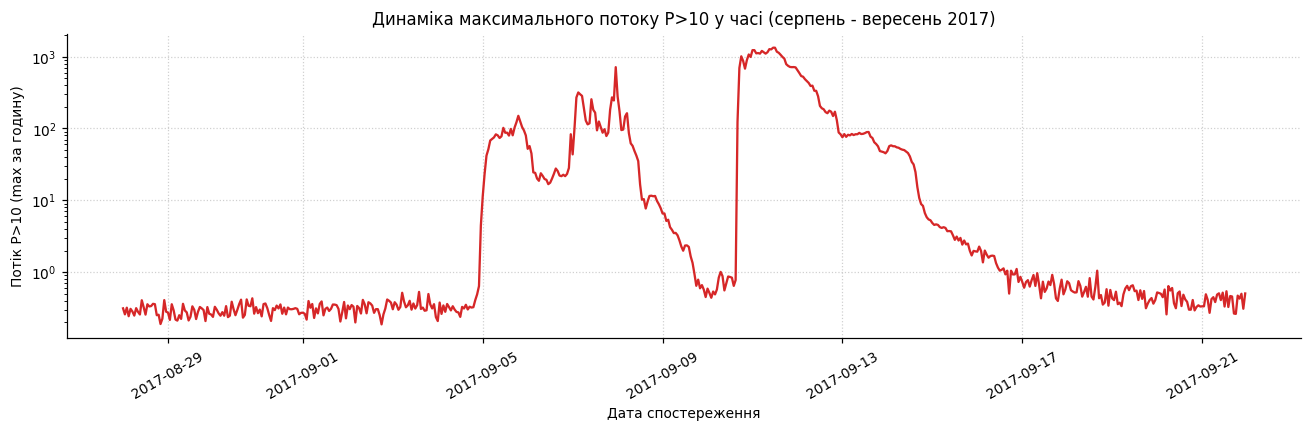

In [23]:
# ВАШ КОД

plt.figure(figsize=(12, 4))

plt.plot(M['ts'], M['P>10_max'], color='#d62728', linewidth=1.5)

plt.title('Динаміка максимального потоку P>10 у часі (серпень - вересень 2017)')
plt.xlabel('Дата спостереження')
plt.ylabel('Потік P>10 (max за годину)')

plt.yscale('log')

plt.grid(True, linestyle=':', alpha=0.6)
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

**Висновок:** Завдяки логарифмічній шкалі на графіку добре видно, як змінювалася космічна погода. Наприкінці серпня та на початку вересня потік P>10 залишався на низькому рівні (близько 1 і менше). Приблизно 5–6 вересня почалося різке зростання активності, а близько 11 вересня потік досяг найбільшого значення — понад 1000. Після цього активність поступово зменшилася і почала повертатися до нормального рівня.


---
# Етап 6. Два графіки одних і тих самих даних

Нижче побудовано два графіки. Дані в них **одні й ті самі** — це той самий стовпець
з тієї самої таблиці, жодне число не змінено.

Виконайте клітинку й подивіться на обидва.

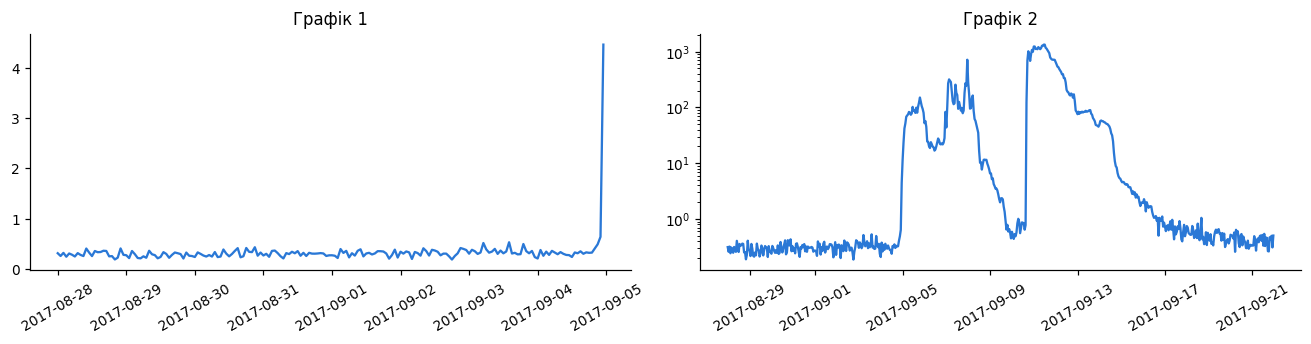

In [24]:
СТОВПЕЦЬ = 'P>10_max'   # <- впишіть назву свого стовпця з МАКСИМУМОМ P>10 за годину

вікно = M[(M['ts'] >= '2017-08-28') & (M['ts'] < '2017-09-05')]

fig, ax = plt.subplots(1, 2, figsize=(12, 3.2))

ax[0].plot(вікно['ts'], вікно[СТОВПЕЦЬ], color='#2a78d6')
ax[0].set_title('Графік 1')
ax[0].tick_params(axis='x', rotation=30)

ax[1].plot(M['ts'], M[СТОВПЕЦЬ], color='#2a78d6')
ax[1].set_yscale('log')
ax[1].set_title('Графік 2')
ax[1].tick_params(axis='x', rotation=30)

fig.tight_layout()
plt.show()

### Завдання 6.1
Дайте відповідь на три питання:

1. Який висновок про космічну погоду у вересні 2017 року зробить людина, яка бачила
   **тільки перший** графік?
2. Який висновок зробить людина, яка бачила **тільки другий**?
3. Чим ці два графіки відрізняються між собою? Назвіть **дві** відмінності —
   вони обидві є в коді вище.

*Жодне число в обох графіках не підроблене. Різниця виникла тільки через те,
як їх побудували.*

**Відповідь 6.1:**

1. Висновок з першого графіка: Можна подумати, що космічна погода була досить спокійною, а потік майже не змінювався і максимум був близько 0.4. Це тому, що на графіку показано тільки перший тиждень.
2. Висновок з другого графіка: Тут уже видно сильний сонячний спалах, оскільки потік зріс у тисячі разів і перевищив значення 1000.
3. Дві відмінності між ними: Різний період часу: у першому графіку використано тільки перший тиждень даних (вікно), а в другому вся таблиця M.
Різна шкала Y: у першому графіку використовується звичайна лінійна шкала, а в другому логарифмічна (ax[1].set_yscale('log')).


### Завдання 6.2
Уявіть, що вам потрібно **одним графіком** чесно показати, що відбувалося в цьому
періоді. Побудуйте його самі й підпишіть заголовком, який формулює висновок.

Поясніть у клітинці нижче, чому ви обрали саме такий вигляд.

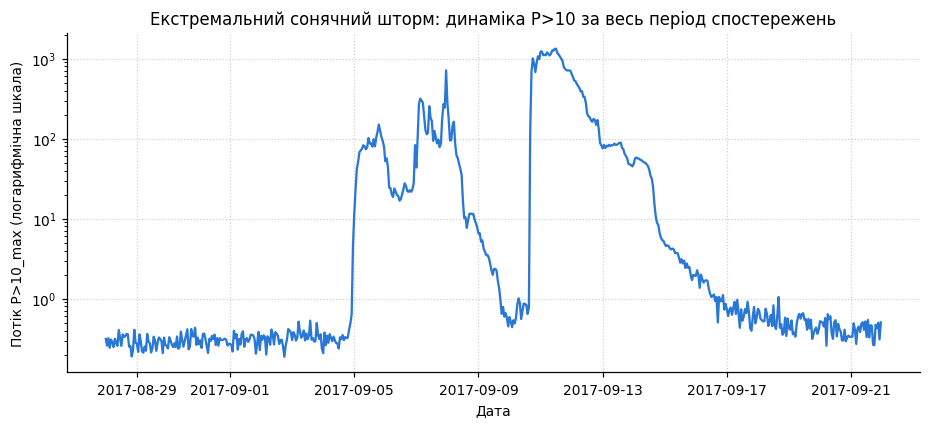

In [25]:
# ВАШ КОД
plt.figure(figsize=(10, 4))
plt.plot(M['ts'], M['P>10_max'], color='#2a78d6')
plt.yscale('log')
plt.title('Екстремальний сонячний шторм: динаміка P>10 за весь період спостережень')
plt.xlabel('Дата')
plt.ylabel('Потік P>10_max (логарифмічна шкала)')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

**Відповідь 6.2:** *(чому ви побудували графік саме так)*

Щоб правильно показати події цього періоду, потрібно взяти весь проміжок часу, а не обмежувати графік лише одним тижнем. Також краще використовувати логарифмічну шкалу по осі Y. При лінійній шкалі через велику різницю між значеннями (від 0.1 до 1000) маленькі значення майже не було б видно. Логарифмічна шкала дозволяє одночасно побачити і спокійні періоди, і великий пік під час спалаху.

---
# Етап 7. Три спостереження та ваше питання

### Завдання 7.1
Запишіть **три спостереження** про ці дані, які ви зробили під час роботи.

Спостереження — це твердження, яке спирається на конкретне число або графік з вашого
ноутбука. Не «дані цікаві», а, наприклад, «максимальне значення потоку у 2000 разів
більше за медіанне, і всі такі години припадають на одні й ті самі три доби».

Для кожного вкажіть, **де саме** у вашій роботі його видно.

**Спостереження 1:**

Середнє арифметичне потоку P>50 у 92 рази більше за його медіану (це видно з розрахунків до Графіка 1). Це означає, що більшість часу потік протонів залишається на низькому рівні, але через рідкісні великі сплески середнє значення сильно збільшується.

**Спостереження 2:**

Радіопотік F10.7 та потік протонів P>10 не мають чіткої лінійної залежності. Коефіцієнт кореляції становить приблизно -0.05 (це видно на Графіку 3). Тобто високий радіопотік не обов'язково означає високий рівень потоку протонів.

**Спостереження 3:**

Більшу частину часу, а саме 68,5%, космічна погода була «тихою» (це видно з Графіка 4). Але приблизно з 5 по 13 вересня відбулася сильна сонячна подія, під час якої потік P>10 зріс у тисячі разів і досяг значення понад 1000 (це видно на Графіку 5).


### Завдання 7.2 — ваше індивідуальне питання
Дайте відповідь на додаткове питання зі свого завдання. Відповідь має спиратися
на обчислення: наведіть код і результат, а потім сформулюйте висновок словами.

Потік E>0.8 у середньому найбільший о 19:00 (значення: 119225.66)


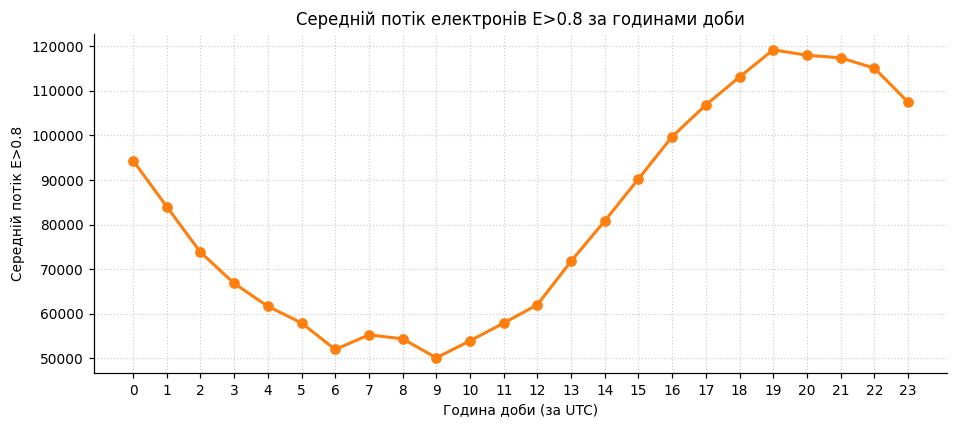

In [26]:
# ВАШ КОД
# О котрій годині доби потік E>0.8 у середньому найбільший? Побудуйте графік середнього за годинами доби

M['hour_of_day'] = M['ts'].dt.hour


e08_by_hour = M.groupby('hour_of_day')['E>0.8_mean'].mean()

max_hour = e08_by_hour.idxmax()
max_val = e08_by_hour.max()

print(f"Потік E>0.8 у середньому найбільший о {max_hour}:00 (значення: {max_val:.2f})")


plt.figure(figsize=(10, 4))
plt.plot(e08_by_hour.index, e08_by_hour.values, marker='o', color='#ff7f0e', linewidth=2)

plt.title('Середній потік електронів E>0.8 за годинами доби')
plt.xlabel('Година доби (за UTC)')
plt.ylabel('Середній потік E>0.8')
plt.xticks(range(0, 24)) 
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

**Відповідь 7.2:** 

Згідно з обчисленнями, найбільше середнє значення потоку електронів E>0.8 спостерігається о **19:00** за UTC. На графіку видно добову зміну потоку: найнижчі значення спостерігаються вранці, приблизно о **6:00–9:00**, після чого потік поступово зростає і досягає найбільшого значення у вечірні години.


---
# Етап 8. Декларація про використання інструментів штучного інтелекту

Користуватися мовними моделями під час виконання цієї роботи **дозволено**. Це
нормальна інженерна практика, і курс про штучний інтелект не має підстав її забороняти.

Обов'язковою є прозорість: ви вказуєте, де саме і як скористалися інструментом —
так само, як у науковій статті вказують використане програмне забезпечення.
**Задекларована допомога порушенням не є.**

Порушенням є інше: здати роботу, яку ви не можете пояснити. На захисті вас попросять
показати конкретний рядок вашого коду, пояснити, чому він саме такий, і внести в нього
невелику зміну на місці. Якщо код згенеровано, але ви його розумієте — робота
зарахована. Якщо не розумієте — не зарахована, незалежно від того, хто його написав.

### Завдання 8.1
Заповніть словник. Для кожного етапу оберіть одне з формулювань:

* `'ні'` — інструментами ШІ не користувався;
* `'синтаксис'` — питав про назву функції або синтаксис, код писав сам;
* `'код, перевірено'` — код згенеровано, я його прочитав, перевірив і розумію;
* `'текст, перероблено'` — згенеровано чернетку тексту, яку я переписав по суті;
* `'текст, як є'` — згенерований текст залишено майже без змін.

Останній варіант не заборонений, але прямо впливає на оцінку: бали ставляться
за висновки, а не за наявність абзацу.

In [27]:
ІНСТРУМЕНТИ_ШІ = 'Gemini'     # напр. 'ChatGPT' або 'не використовував'

ДЕКЛАРАЦІЯ = {
    'етапи 1–2, читання файлу та розбір таблиць': 'синтаксис',
    'етап 3, паспорт даних і дивні значення':     'код, перевірено',
    'етап 4, об’єднання таблиць':                 'код, перевірено',
    'етап 5, побудова графіків':                  'код, перевірено',
    'етап 5, формулювання висновків':             'текст, перероблено',
    'етапи 6–7, порівняння графіків і спостереження': 'ні',
}

# Що саме ви перевірили за згенерованим кодом чи текстом — конкретно:
# які числа звірили, що переписали, де знайшли помилку.
ЩО_ПЕРЕВІРЕНО = '''
Перевірив розмірності отриманих таблиць, вийшло 7200, 25 і 601 рядок, що збігається з очікуваним, 
поправив застарілий синтаксис pandas ('1H' замінив на '1h' при ресемплінгу, бо стара версія видавала попередження).
Висновки до графіків переформулював власними словами, спираючись на те, що видно на самих графіках.
Останні етапи (порівняння графіків і спостереження) виконував самостійно, без допомоги ШІ.
'''

# True означає: я можу пояснити кожен рядок свого коду, відтворити будь-який
# результат цієї роботи та внести зміни в код на вимогу під час захисту.
ПІДТВЕРДЖУЮ = True

In [28]:
# --- перевірка повноти декларації: клітинку не редагувати --------------------
ДОЗВОЛЕНІ = {'ні', 'синтаксис', 'код, перевірено', 'текст, перероблено', 'текст, як є'}

assert ІНСТРУМЕНТИ_ШІ.strip(), 'Вкажіть інструменти або напишіть «не використовував»'
порожні = [k for k, v in ДЕКЛАРАЦІЯ.items() if not str(v).strip()]
assert not порожні, 'Не заповнено пункти декларації: %s' % '; '.join(порожні)
чужі = {v for v in ДЕКЛАРАЦІЯ.values() if v not in ДОЗВОЛЕНІ}
assert not чужі, 'Недопустимі значення: %s. Оберіть з переліку вище.' % ', '.join(sorted(чужі))
assert len(ЩО_ПЕРЕВІРЕНО.strip()) >= 120, ('Опишіть конкретніше, що саме ви перевірили '
                                           '(зараз %d символів, потрібно щонайменше 120)'
                                           % len(ЩО_ПЕРЕВІРЕНО.strip()))
assert ПІДТВЕРДЖУЮ is True, 'Підтвердьте, що можете пояснити власний код на захисті'

print('ДЕКЛАРАЦІЯ ПРО ВИКОРИСТАННЯ ІНСТРУМЕНТІВ ШІ')
print('=' * 78)
print('%-46s %s' % ('автор:', ПІБ))
print('%-46s %s' % ('інструменти:', ІНСТРУМЕНТИ_ШІ))
print('-' * 78)
for k, v in ДЕКЛАРАЦІЯ.items():
    print('%-46s %s' % (k + ':', v))
print('-' * 78)
print('перевірено автором:')
print(ЩО_ПЕРЕВІРЕНО)
print('=' * 78)
print('Автор підтверджує, що може пояснити кожен рядок коду під час захисту.')

ДЕКЛАРАЦІЯ ПРО ВИКОРИСТАННЯ ІНСТРУМЕНТІВ ШІ
автор:                                         Стик Назарій Олегович
інструменти:                                   Gemini
------------------------------------------------------------------------------
етапи 1–2, читання файлу та розбір таблиць:    синтаксис
етап 3, паспорт даних і дивні значення:        код, перевірено
етап 4, об’єднання таблиць:                    код, перевірено
етап 5, побудова графіків:                     код, перевірено
етап 5, формулювання висновків:                текст, перероблено
етапи 6–7, порівняння графіків і спостереження: ні
------------------------------------------------------------------------------
перевірено автором:

Перевірив розмірності отриманих таблиць, вийшло 7200, 25 і 601 рядок, що збігається з очікуваним, 
поправив застарілий синтаксис pandas ('1H' замінив на '1h' при ресемплінгу, бо стара версія видавала попередження).
Висновки до графіків переформулював власними словами, спираючись на те, що в

---
# Крок 9. Збереження результату та фінальна самоперевірка

Об'єднана таблиця знадобиться вам у лабораторних роботах № 3 і № 4 — збережіть її
й не втрачайте до кінця семестру.

In [29]:
M.to_csv('master_hourly.csv', index=False)
print('збережено:', M.shape)

збережено: (600, 22)


In [30]:
# --- фінальна самоперевірка --------------------------------------------------
перевірки = {
    'ПІБ і варіант заповнено':        bool(ПІБ) and bool(ВАРІАНТ),
    'таблиця A (7200 рядків)':        len(A) == 7200,
    'таблиця B (25 рядків)':          len(B) == 25,
    'таблиця C (601 рядок)':          len(C) == 601,
    'таблиці об’єднано':              M is not None and 590 <= len(M) <= 605,
    'стовпець «група» є':             'група' in M.columns,
    'усі дати у 2017 році':           int(pd.to_datetime(M['ts']).dt.year.min()) == 2017,
    'декларацію заповнено':           bool(ІНСТРУМЕНТИ_ШІ.strip()) and ПІДТВЕРДЖУЮ is True,
}
for k, v in перевірки.items():
    print(('OK   ' if v else 'НЕ ОК') + '  ' + k)

if all(перевірки.values()):
    print('\nТехнічна частина роботи виконана.')
    print('Тепер переконайтеся, що заповнені ВСІ клітинки з відповідями та висновками,')
    print('і виконайте Kernel → Restart & Run All перед здачею.')

OK     ПІБ і варіант заповнено
OK     таблиця A (7200 рядків)
OK     таблиця B (25 рядків)
OK     таблиця C (601 рядок)
OK     таблиці об’єднано
OK     стовпець «група» є
OK     усі дати у 2017 році
OK     декларацію заповнено

Технічна частина роботи виконана.
Тепер переконайтеся, що заповнені ВСІ клітинки з відповідями та висновками,
і виконайте Kernel → Restart & Run All перед здачею.
